In [1]:
from curl_cffi import requests

url = "https://www.sofascore.com/api/v1/event/14024015/shotmap"

response = requests.get(url)
response.status_code
response.json()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/116.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Kaoru Mitoma', 'slug': 'mitoma-kaoru', 'shortName': 'K. Mitoma', 'position': 'M', 'jerseyNumber': '22', 'userCount': 20388, 'gender': 'M', 'sofascoreId': 'KaoruM', 'id': 936849, 'fieldTranslations': {'nameTranslation': {'ar': 'ميتوما، كاورو', 'bn': 'মিতোমা, কাওরু', 'hi': 'मिटोमा, काओरू'}, 'shortNameTranslation': {'ar': 'ك. ميتوما', 'bn': 'কে. মিতোমা', 'hi': 'के. काओरू'}}}, 'isHome': True, 'shotType': 'save', 'situation': 'assisted', 'playerCoordinates': {'x': 3.9, 'y': 35.2, 'z': 0}, 'bodyPart': 'left-foot', 'goalMouthLocation': 'low-centre', 'goalMouthCoordinates': {'x': 0, 'y': 51.6, 'z': 5.1}, 'blockCoordinates': {'x': 2.7, 'y': 39, 'z': 0}, 'xg': 0.098975606262684, 'xgot': 0.16425275802612, 'goalkeeper': {'name': 'Giorgi Mamardashvili', 'slug': 'giorgi-mamardashvili', 'shortName': 'G. Mamardashvili', 'position': 'G', 'jerseyNumber': '25', 'userCount': 17677, 'gender': 'M', 'sofascoreId': 'mamardashvili', 'id': 930997, 'fieldTranslations': {'nam

In [2]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Kaoru Mitoma', 'slug': 'mitoma-kaoru...    True     save   
1  {'name': 'Yasin Ayari', 'slug': 'yasin-ayari',...    True    block   
2  {'name': 'Jan Paul van Hecke', 'slug': 'jan-pa...    True     save   
3  {'name': 'Cody Gakpo', 'firstName': '', 'lastN...   False     save   
4  {'name': 'Federico Chiesa', 'slug': 'federico-...   False    block   

    situation              playerCoordinates    bodyPart goalMouthLocation  \
0    assisted  {'x': 3.9, 'y': 35.2, 'z': 0}   left-foot        low-centre   
1      corner  {'x': 9.1, 'y': 53.8, 'z': 0}  right-foot        low-centre   
2      corner    {'x': 4, 'y': 39.3, 'z': 0}        head         low-right   
3  fast-break  {'x': 9.8, 'y': 28.4, 'z': 0}  right-foot        low-centre   
4  fast-break  {'x': 9.5, 'y': 33.1, 'z': 0}   left-foot        low-centre   

            goalMouthCoordinates               blockCoordinates        xg  \
0  {'x': 0, 'y'

In [3]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

               player  team_home shot_type   situation   body_part    x     y  \
0        Kaoru Mitoma       True      save    assisted   left-foot  3.9  35.2   
1         Yasin Ayari       True     block      corner  right-foot  9.1  53.8   
2  Jan Paul van Hecke       True      save      corner        head  4.0  39.3   
3          Cody Gakpo      False      save  fast-break  right-foot  9.8  28.4   
4     Federico Chiesa      False     block  fast-break   left-foot  9.5  33.1   

         xg  minute  
0  0.098976      90  
1  0.071870      87  
2  0.045229      87  
3  0.034478      86  
4  0.071349      78  


In [4]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Kaoru Mitoma,True,save,assisted,left-foot,3.9,35.2,0.098976,90
1,Yasin Ayari,True,block,corner,right-foot,9.1,53.8,0.071870,87
2,Jan Paul van Hecke,True,save,corner,head,4.0,39.3,0.045229,87
3,Cody Gakpo,False,save,fast-break,right-foot,9.8,28.4,0.034478,86
4,Federico Chiesa,False,block,fast-break,left-foot,9.5,33.1,0.071349,78


In [5]:
shots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player     28 non-null     object 
 1   team_home  28 non-null     bool   
 2   shot_type  28 non-null     object 
 3   situation  28 non-null     object 
 4   body_part  28 non-null     object 
 5   x          28 non-null     float64
 6   y          28 non-null     float64
 7   xg         28 non-null     float64
 8   minute     28 non-null     int64  
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 1.9+ KB


In [6]:
shots_df.groupby("team_home")["shot_type"].count()

,shot_type
team_home,
False,12
True,16


In [7]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                 player  Total_Shots
0   Alexis Mac Allister            3
1            Cody Gakpo            2
2          Curtis Jones            1
3         Danny Welbeck            3
4           Diego Gómez            3
5    Dominik Szoboszlai            3
6       Federico Chiesa            1
7        Ferdi Kadıoğlu            1
8         Florian Wirtz            1
9      Jack Hinshelwood            1
10         James Milner            2
11   Jan Paul van Hecke            1
12         Kaoru Mitoma            1
13         Mats Wieffer            2
14         Miloš Kerkez            1
15       Yankuba Minteh            1
16          Yasin Ayari            1


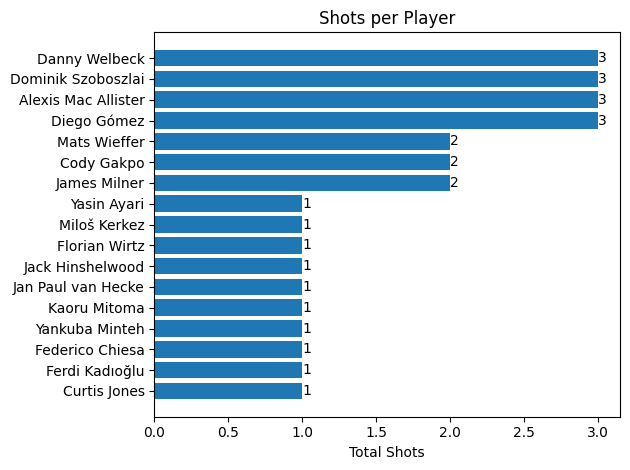

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = {
     "player": [
        "Alexis Mac Allister", "Cody Gakpo", "Curtis Jones", "Danny Welbeck",
        "Diego Gómez", "Dominik Szoboszlai", "Federico Chiesa", "Ferdi Kadıoğlu",
        "Florian Wirtz", "Jack Hinshelwood", "James Milner", "Jan Paul van Hecke",
        "Kaoru Mitoma", "Mats Wieffer", "Miloš Kerkez", "Yankuba Minteh", "Yasin Ayari"
    ],
    "shots": [3, 2, 1, 3, 3, 3, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1]
}

df = pd.DataFrame(data)

# Sort values
df = df.sort_values(by="shots", ascending=True)

# Plot
plt.figure()
bars = plt.barh(df["player"], df["shots"])

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va='center')

plt.xlabel("Total Shots")
plt.title("Shots per Player")
plt.tight_layout()
plt.show()

In [9]:
shots_df.groupby("player")["xg"].sum().sort_values(ascending=False)

,xg
player,
Danny Welbeck,1.074228
Miloš Kerkez,0.372082
Diego Gómez,0.354572
Yankuba Minteh,0.231007
Mats Wieffer,0.169495
Alexis Mac Allister,0.137240
Cody Gakpo,0.105158
Kaoru Mitoma,0.098976
Dominik Szoboszlai,0.092673


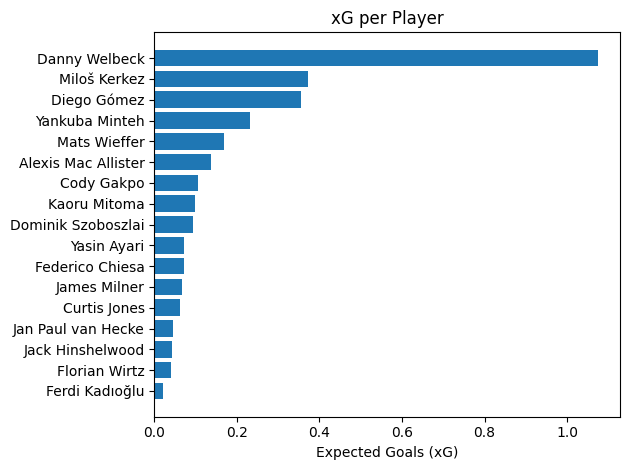

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = {
    "player": [
        "Danny Welbeck", "Miloš Kerkez", "Diego Gómez", "Yankuba Minteh",
        "Mats Wieffer", "Alexis Mac Allister", "Cody Gakpo", "Kaoru Mitoma",
        "Dominik Szoboszlai", "Yasin Ayari", "Federico Chiesa", "James Milner",
        "Curtis Jones", "Jan Paul van Hecke", "Jack Hinshelwood", "Florian Wirtz",
        "Ferdi Kadıoğlu"
    ],
    "xg": [
        1.074228, 0.372082, 0.354572, 0.231007,
        0.169495, 0.137240, 0.105158, 0.098976,
        0.092673, 0.071870, 0.071349, 0.067010,
        0.061128, 0.045229, 0.043337, 0.039403,
        0.021566
    ]
}

df = pd.DataFrame(data)

# Sort values (important!)
df = df.sort_values(by="xg", ascending=True)


# Plot
plt.figure()
plt.barh(df["player"], df["xg"])
plt.xlabel("Expected Goals (xG)")
plt.title("xG per Player")
plt.tight_layout()
plt.show()

In [11]:
shots_df.groupby("team_home")["xg"].sum()

,xg
team_home,
False,0.879033
True,2.177289


In [12]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

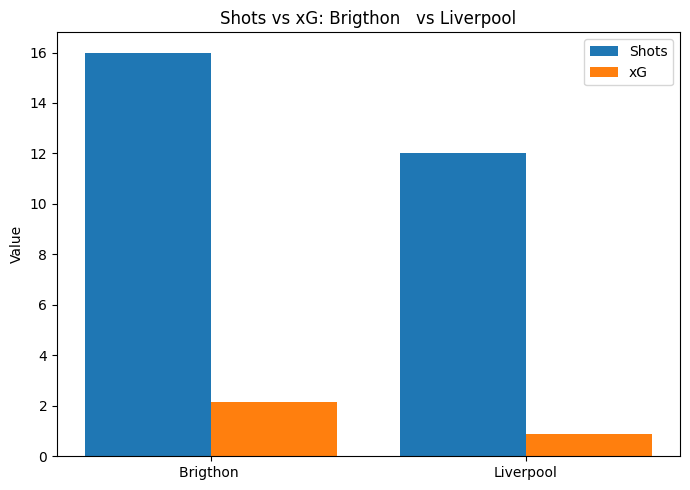

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Team": ["Brigthon ", "Liverpool"],
    "Shots": [16, 12],
    "xG": [2.17, 0.88]
}

df = pd.DataFrame(data)

x = range(len(df))

plt.figure(figsize=(7,5))

plt.bar(x, df["Shots"], width=0.4, label="Shots")
plt.bar([i + 0.4 for i in x], df["xG"], width=0.4, label="xG")

plt.xticks([i + 0.2 for i in x], df["Team"])
plt.ylabel("Value")
plt.title("Shots vs xG: Brigthon   vs Liverpool")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# Count shots per situation for each team
situation_counts = shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation         
False      assisted              5
           fast-break            3
           regular               2
           corner                1
           free-kick             1
True       corner                7
           assisted              5
           fast-break            1
           free-kick             1
           regular               1
           throw-in-set-piece    1
Name: count, dtype: int64


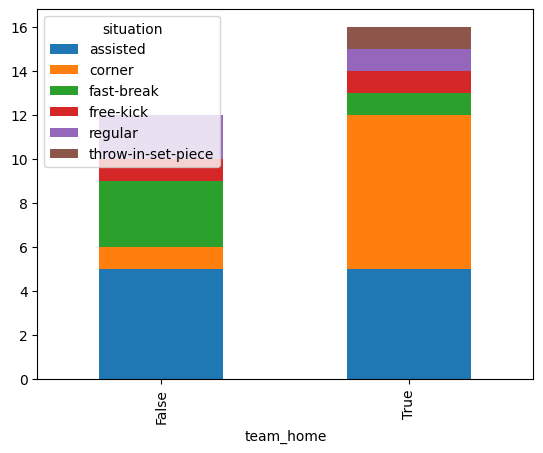

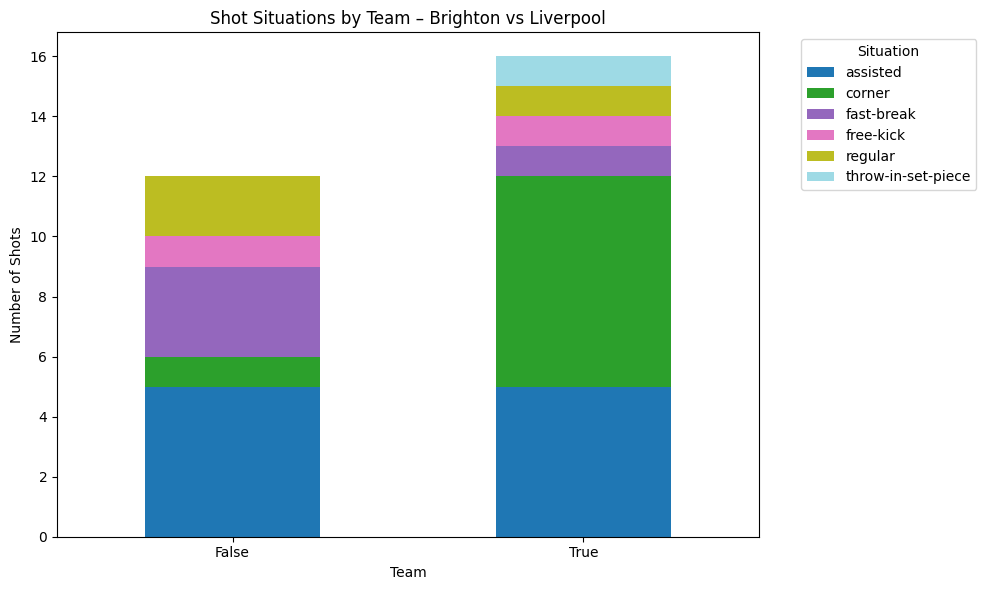

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "team_home": [
        False, False, False, False, False,
        True, True, True, True, True, True
    ],
    "situation": [
        "assisted", "fast-break", "regular", "corner", "free-kick",
        "corner", "assisted", "fast-break", "free-kick", "regular", "throw-in-set-piece"
    ],
    "shots": [5, 3, 2, 1, 1, 7, 5, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
pivot = df.pivot(index="team_home", columns="situation", values="shots").fillna(0)

pivot.plot(kind="bar", stacked=True)

pivot.plot(kind="bar", stacked=True, figsize=(10,6), colormap='tab20')
plt.xlabel("Team")
plt.ylabel("Number of Shots")
plt.title("Shot Situations by Team – Brighton vs Liverpool")
plt.xticks(rotation=0)
plt.legend(title="Situation", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [16]:
# Count number of shots per player per situation, keeping team info
situation_counts = shots_df.groupby(["team_home", "player"])["situation"].value_counts().reset_index(name="shots")
print(situation_counts)

    team_home               player           situation  shots
0       False  Alexis Mac Allister            assisted      2
1       False  Alexis Mac Allister              corner      1
2       False           Cody Gakpo            assisted      1
3       False           Cody Gakpo          fast-break      1
4       False         Curtis Jones            assisted      1
5       False   Dominik Szoboszlai            assisted      1
6       False   Dominik Szoboszlai          fast-break      1
7       False   Dominik Szoboszlai           free-kick      1
8       False      Federico Chiesa          fast-break      1
9       False        Florian Wirtz             regular      1
10      False         Miloš Kerkez             regular      1
11       True        Danny Welbeck            assisted      1
12       True        Danny Welbeck              corner      1
13       True        Danny Welbeck  throw-in-set-piece      1
14       True          Diego Gómez            assisted      1
15      

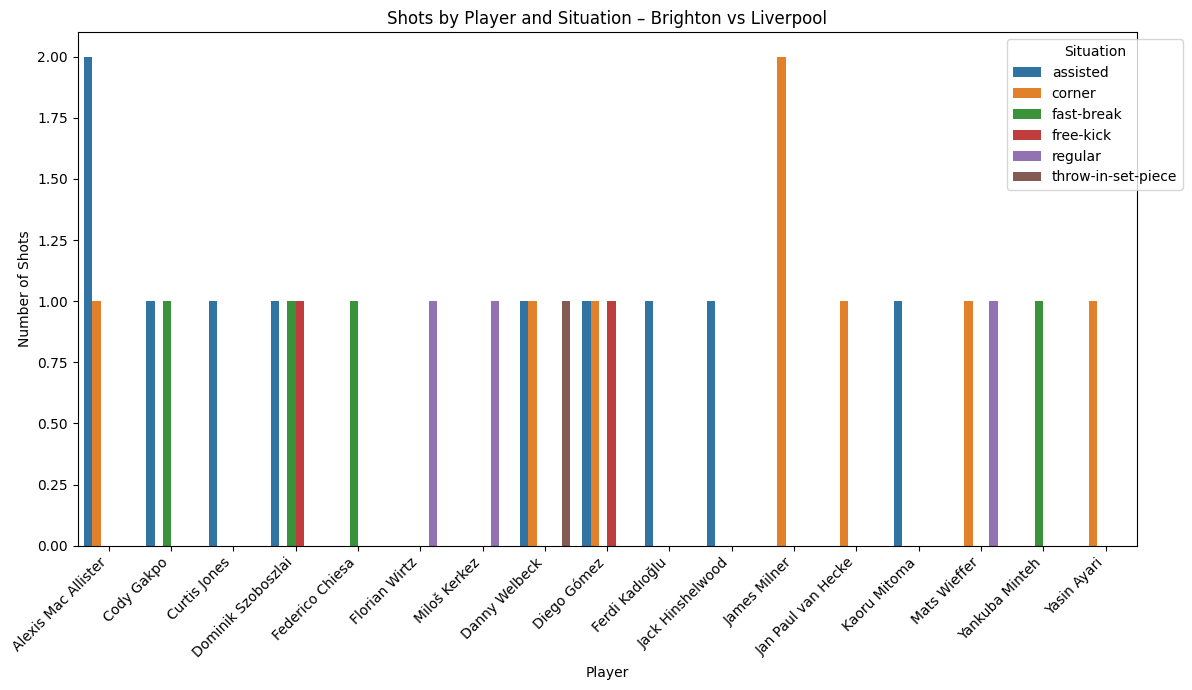

In [17]:
import pandas as pd

data = {
    "team_home": [
        False, False, False, False, False, False, False, False, False, False, False,
        True, True, True, True, True, True, True, True, True, True, True, True, True, True, True
    ],
    "player": [
        "Alexis Mac Allister", "Alexis Mac Allister", "Cody Gakpo", "Cody Gakpo", "Curtis Jones",
        "Dominik Szoboszlai", "Dominik Szoboszlai", "Dominik Szoboszlai", "Federico Chiesa", "Florian Wirtz", "Miloš Kerkez",
        "Danny Welbeck", "Danny Welbeck", "Danny Welbeck", "Diego Gómez", "Diego Gómez", "Diego Gómez",
        "Ferdi Kadıoğlu", "Jack Hinshelwood", "James Milner", "Jan Paul van Hecke", "Kaoru Mitoma",
        "Mats Wieffer", "Mats Wieffer", "Yankuba Minteh", "Yasin Ayari"
    ],
    "situation": [
        "assisted", "corner", "assisted", "fast-break", "assisted",
        "assisted", "fast-break", "free-kick", "fast-break", "regular", "regular",
        "assisted", "corner", "throw-in-set-piece", "assisted", "corner", "free-kick",
        "assisted", "assisted", "corner", "corner", "assisted", "corner", "regular",
        "fast-break", "corner"
    ],
    "shots": [
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)
import seaborn as sns

plt.figure(figsize=(12,7))
sns.barplot(data=df, x='player', y='shots', hue='situation')
plt.title('Shots by Player and Situation – Brighton vs Liverpool')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Shots')
plt.xlabel('Player')
plt.legend(title='Situation', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

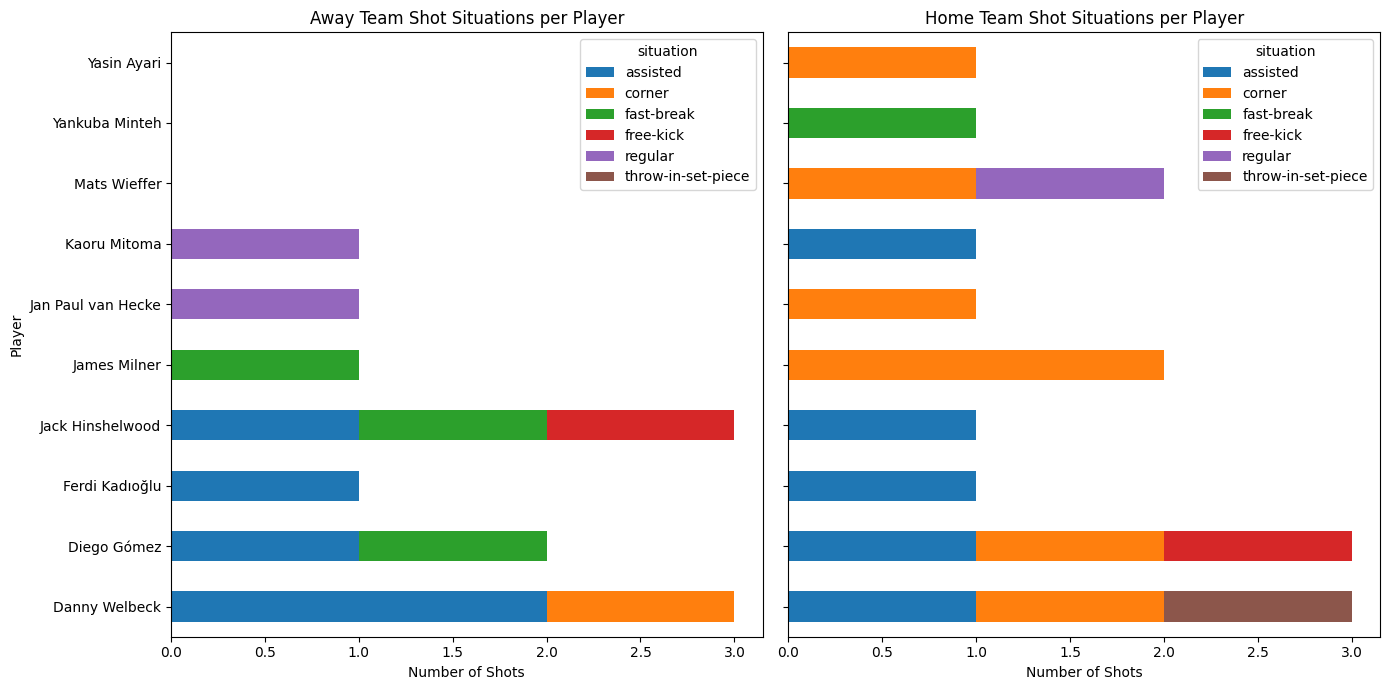

In [18]:
# Pivot for stacked bar chart
pivot = df.pivot_table(
    index=["team_home","player"],
    columns="situation",
    values="shots",
    fill_value=0
)

# Separate Home and Away Teams
away_shots= pivot.loc[True]
home_shots = pivot.loc[False]

# Plotting
fig, axes = plt.subplots(1,2, figsize=(14,7), sharey=True)

# Home team
home_shots.plot(kind="barh", stacked=True, ax=axes[0])
axes[0].set_title("Away Team Shot Situations per Player")
axes[0].set_xlabel("Number of Shots")
axes[0].set_ylabel("Player")

# Away team
away_shots.plot(kind="barh", stacked=True, ax=axes[1])
axes[1].set_title("Home Team Shot Situations per Player")
axes[1].set_xlabel("Number of Shots")

plt.tight_layout()
plt.show()

In [19]:
shot_type_counts = shots_df.groupby("team_home")["shot_type"].value_counts()
print(shot_type_counts)

team_home  shot_type
False      miss         4
           save         4
           block        3
           goal         1
True       miss         7
           save         5
           block        2
           goal         2
Name: count, dtype: int64


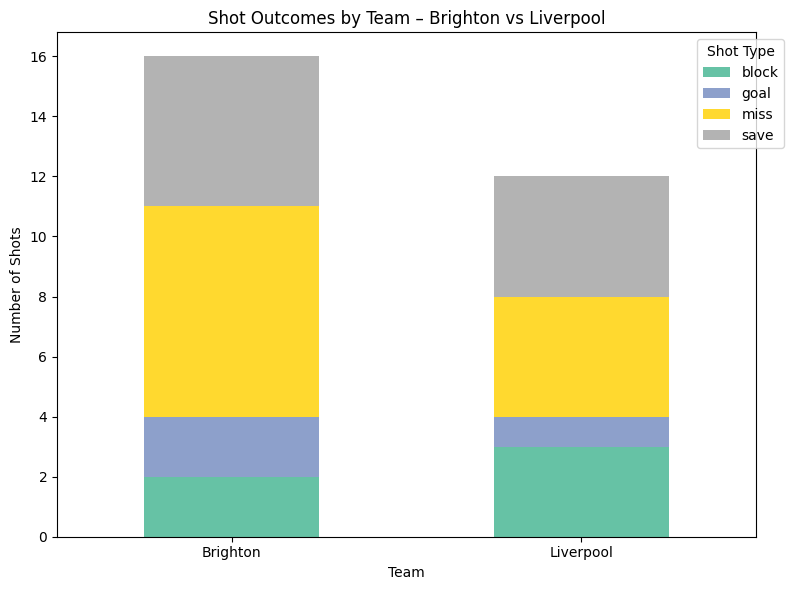

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "team": ["Liverpool", "Liverpool", "Liverpool", "Liverpool",
             "Brighton", "Brighton", "Brighton", "Brighton"],
    "shot_type": ["miss", "save", "block", "goal",
                  "miss", "save", "block", "goal"],
    "shots": [4, 4, 3, 1, 7, 5, 2, 2]
}

df = pd.DataFrame(data)

# Pivot for stacked bar chart
pivot = df.pivot(index="team", columns="shot_type", values="shots").fillna(0)

# Plot
pivot.plot(kind="bar", stacked=True, figsize=(8,6), colormap='Set2')
plt.title("Shot Outcomes by Team – Brighton vs Liverpool")
plt.ylabel("Number of Shots")
plt.xlabel("Team")
plt.xticks(rotation=0)
plt.legend(title="Shot Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [21]:
# Count number of shots per player per situation, keeping team info
shot_type_counts = shots_df.groupby(["team_home", "player"])["shot_type"].value_counts().reset_index(name="shots")
print(shot_type_counts)

    team_home               player shot_type  shots
0       False  Alexis Mac Allister     block      1
1       False  Alexis Mac Allister      miss      1
2       False  Alexis Mac Allister      save      1
3       False           Cody Gakpo     block      1
4       False           Cody Gakpo      save      1
5       False         Curtis Jones      save      1
6       False   Dominik Szoboszlai      miss      3
7       False      Federico Chiesa     block      1
8       False        Florian Wirtz      save      1
9       False         Miloš Kerkez      goal      1
10       True        Danny Welbeck      goal      2
11       True        Danny Welbeck     block      1
12       True          Diego Gómez      miss      2
13       True          Diego Gómez      save      1
14       True       Ferdi Kadıoğlu      save      1
15       True     Jack Hinshelwood      miss      1
16       True         James Milner      miss      2
17       True   Jan Paul van Hecke      save      1
18       Tru

In [22]:
# Count number of shots per player per situation, keeping team info
shot_type_counts = shots_df.groupby(["team_home", "player","situation"])["shot_type"].value_counts().reset_index(name="shots")
print(shot_type_counts)

    team_home               player           situation shot_type  shots
0       False  Alexis Mac Allister            assisted     block      1
1       False  Alexis Mac Allister            assisted      save      1
2       False  Alexis Mac Allister              corner      miss      1
3       False           Cody Gakpo            assisted     block      1
4       False           Cody Gakpo          fast-break      save      1
5       False         Curtis Jones            assisted      save      1
6       False   Dominik Szoboszlai            assisted      miss      1
7       False   Dominik Szoboszlai          fast-break      miss      1
8       False   Dominik Szoboszlai           free-kick      miss      1
9       False      Federico Chiesa          fast-break     block      1
10      False        Florian Wirtz             regular      save      1
11      False         Miloš Kerkez             regular      goal      1
12       True        Danny Welbeck            assisted      goal

In [23]:
import pandas as pd

data = {
    "team_home": [
        False, False, False, False, False, False, False, False, False, False, False, False,
        True, True, True, True, True, True, True, True, True, True, True, True, True, True, True
    ],
    "player": [
        "Alexis Mac Allister", "Alexis Mac Allister", "Alexis Mac Allister", "Cody Gakpo", "Cody Gakpo",
        "Curtis Jones", "Dominik Szoboszlai", "Dominik Szoboszlai", "Dominik Szoboszlai", "Federico Chiesa",
        "Florian Wirtz", "Miloš Kerkez", "Danny Welbeck", "Danny Welbeck", "Danny Welbeck", "Diego Gómez",
        "Diego Gómez", "Diego Gómez", "Ferdi Kadıoğlu", "Jack Hinshelwood", "James Milner",
        "Jan Paul van Hecke", "Kaoru Mitoma", "Mats Wieffer", "Mats Wieffer", "Yankuba Minteh", "Yasin Ayari"
    ],
    "situation": [
        "assisted", "assisted", "corner", "assisted", "fast-break", "assisted", "assisted", "fast-break", "free-kick",
        "fast-break", "regular", "regular", "assisted", "corner", "throw-in-set-piece", "assisted", "corner", "free-kick",
        "assisted", "assisted", "corner", "corner", "assisted", "corner", "regular", "regular", "fast-break", "corner"
    ][:27],  # slice to ensure length is 27
    "shot_type": [
        "block", "save", "miss", "block", "save", "save", "miss", "miss", "miss", "block", "save", "goal",
        "goal", "block", "goal", "miss", "miss", "save", "save", "miss", "miss", "save", "save", "miss", "miss", "save", "block"
    ],
    "shots": [
        1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1
    ]
}

df = pd.DataFrame(data)



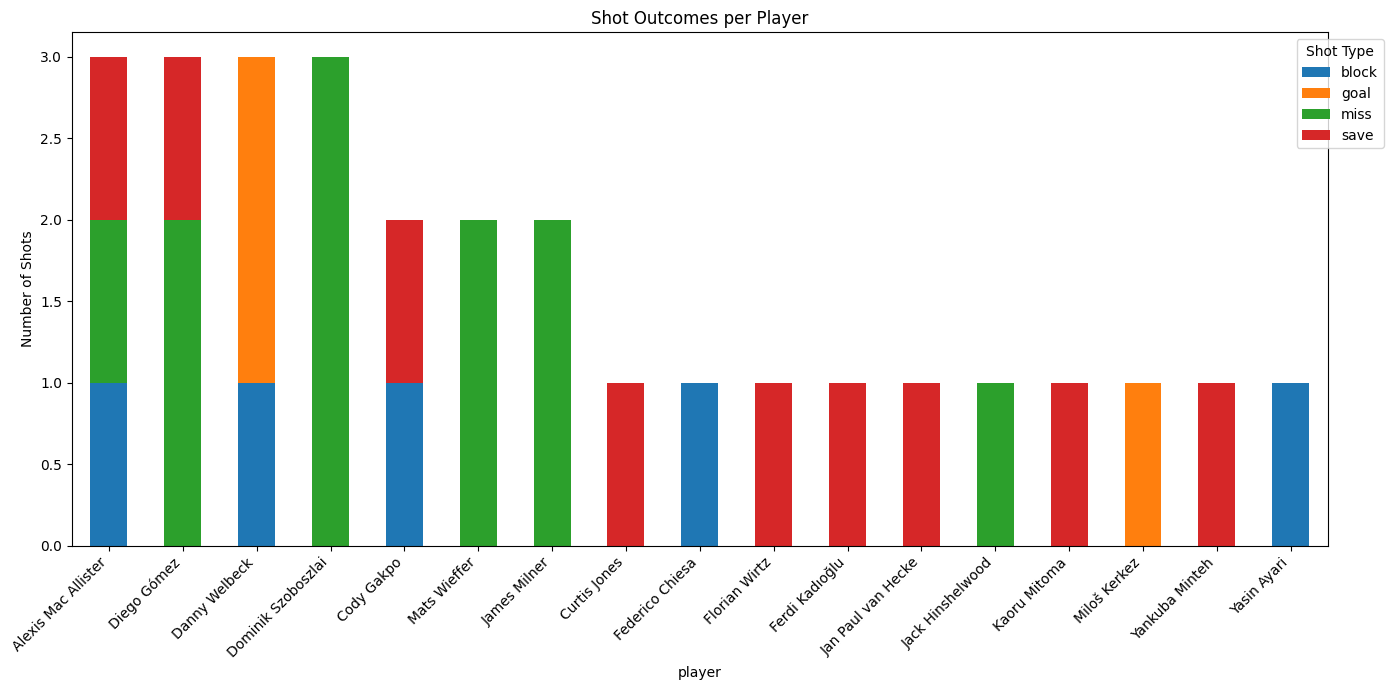

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
pivot_df = shots_df.pivot_table(
    index='player',
    columns='shot_type',
    aggfunc='size',
    fill_value=0
)

# Sort by total involvement
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='total', ascending=False)
pivot_df.drop('total', axis=1, inplace=True)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(14,7))
plt.ylabel("Number of Shots")
plt.title("Shot Outcomes per Player")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Shot Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [25]:
shots_df["body_part"].value_counts()

,count
body_part,
right-foot,14
left-foot,8
head,6


In [26]:
# Count number of shots per player per situation, keeping team info
body_part_counts = shots_df.groupby(["team_home", "player"])["body_part"].value_counts().reset_index(name="shots")
print(body_part_counts)

    team_home               player   body_part  shots
0       False  Alexis Mac Allister        head      2
1       False  Alexis Mac Allister  right-foot      1
2       False           Cody Gakpo  right-foot      2
3       False         Curtis Jones   left-foot      1
4       False   Dominik Szoboszlai  right-foot      3
5       False      Federico Chiesa   left-foot      1
6       False        Florian Wirtz  right-foot      1
7       False         Miloš Kerkez   left-foot      1
8        True        Danny Welbeck        head      1
9        True        Danny Welbeck   left-foot      1
10       True        Danny Welbeck  right-foot      1
11       True          Diego Gómez  right-foot      2
12       True          Diego Gómez        head      1
13       True       Ferdi Kadıoğlu  right-foot      1
14       True     Jack Hinshelwood   left-foot      1
15       True         James Milner   left-foot      1
16       True         James Milner  right-foot      1
17       True   Jan Paul van

In [27]:
bodypart_xg = shots_df.groupby('body_part')['xg'].sum().reset_index()

# Sort for better visualization
bodypart_xg = bodypart_xg.sort_values(by='xg', ascending=False)

print(bodypart_xg)

    body_part        xg
1   left-foot  1.666291
0        head  0.847275
2  right-foot  0.542757


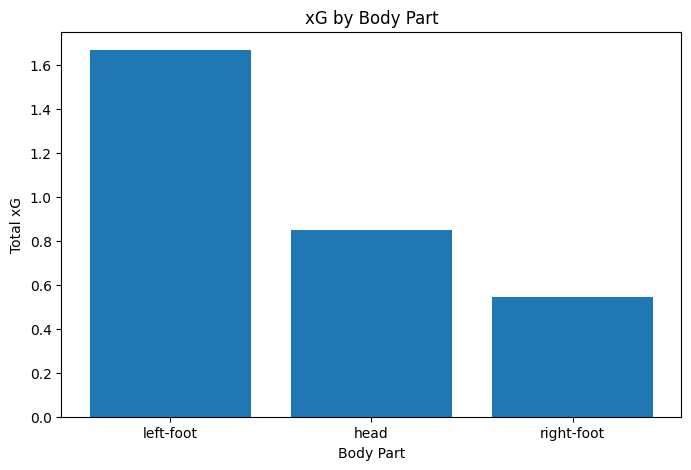

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(bodypart_xg['body_part'], bodypart_xg['xg'])
plt.ylabel("Total xG")
plt.xlabel("Body Part")
plt.title("xG by Body Part")
plt.xticks(rotation=0)
plt.show()

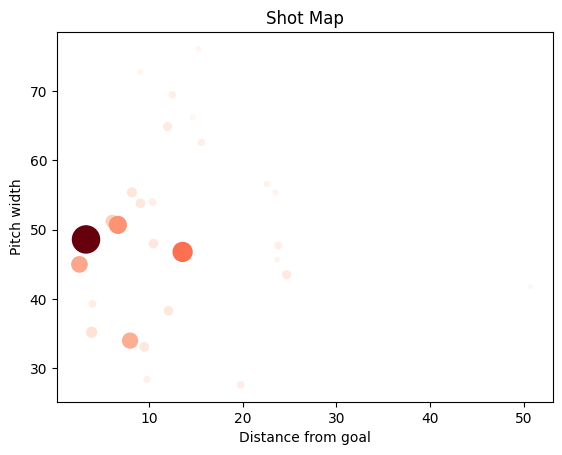

In [29]:
plt.scatter(shots_df["x"], shots_df["y"], c=shots_df["xg"], s=shots_df["xg"]*500, cmap="Reds")
plt.xlabel("Distance from goal")
plt.ylabel("Pitch width")
plt.title("Shot Map")
plt.show()

In [30]:
Brigthon = shots_df[shots_df["team_home"] == True]
Liverpool = shots_df[shots_df["team_home"] == False]

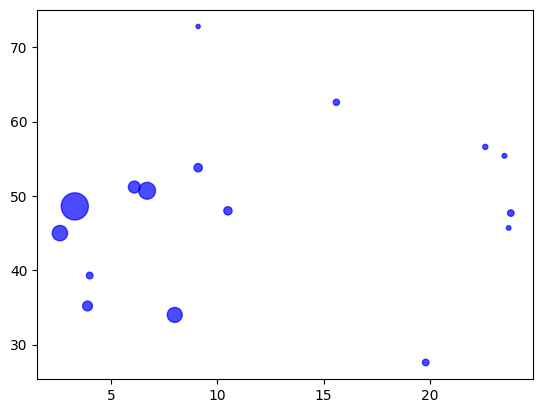

In [31]:
plt.scatter(
    Brigthon["x"],
    Brigthon["y"],
    s=Brigthon["xg"]*500,
    c="blue",
    edgecolor="blue",
    alpha=0.7,
    label="Brigthon"
)

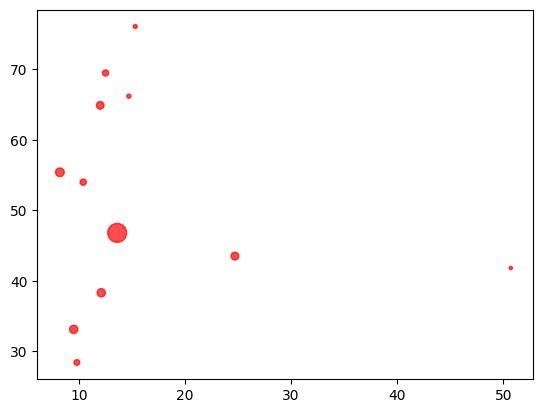

In [32]:
plt.scatter(
    Liverpool["x"],
    Liverpool["y"],
    s=Liverpool["xg"]*500,
    c="red",
    edgecolor="red",
    alpha=0.7,
    label="Liverpool"
)

In [33]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.2 MB/s eta 0:00:00


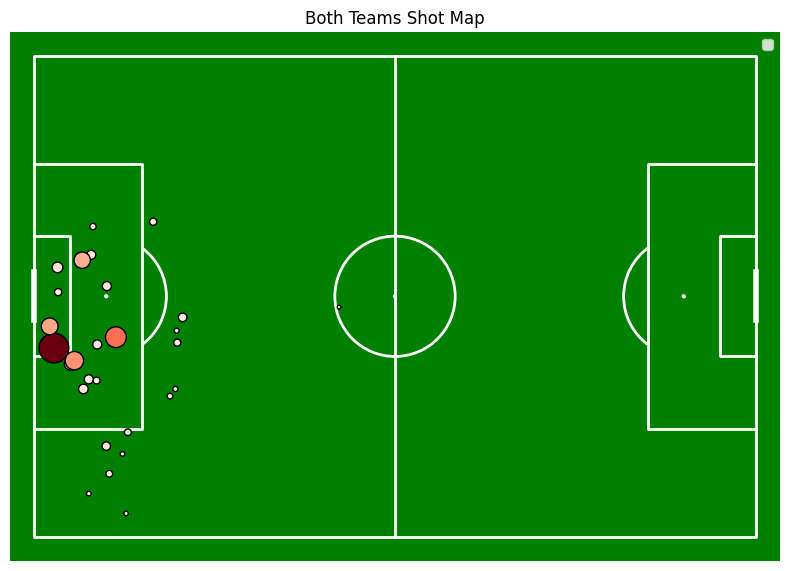

In [34]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    shots_df["x"],
    shots_df["y"],
    s=shots_df["xg"]*600,
    c=shots_df["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Both Teams Shot Map")
plt.legend()
plt.show()

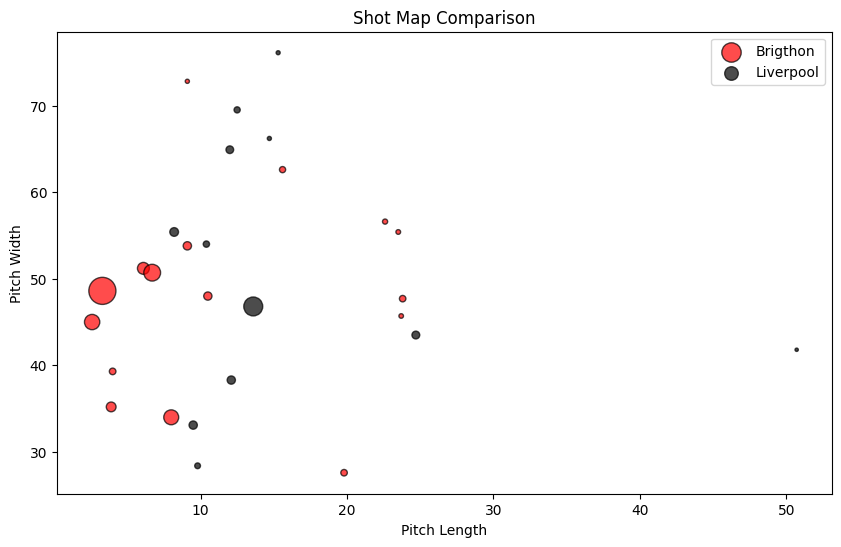

In [35]:
plt.figure(figsize=(10,6))

home = shots_df[shots_df["team_home"] == True]
away = shots_df[shots_df["team_home"] == False]

plt.scatter(home["x"], home["y"], s=home["xg"]*500,
            c="red", edgecolor="black", alpha=0.7, label="Brigthon")

plt.scatter(away["x"], away["y"], s=away["xg"]*500,
            c="black", edgecolor="black", alpha=0.7, label="Liverpool")

plt.title("Shot Map Comparison")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Width")
plt.legend()

plt.show()

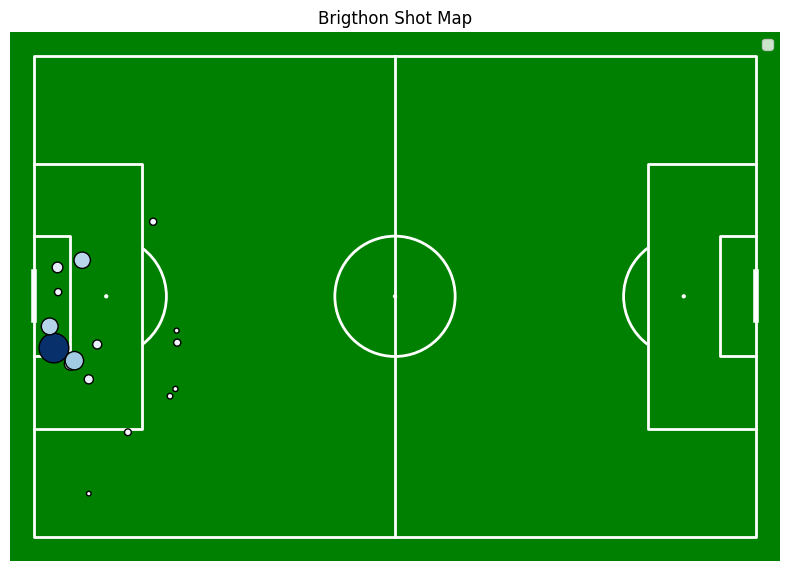

In [36]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    Brigthon["x"],
    Brigthon["y"],
    s=Brigthon["xg"]*600,
    c=Brigthon["xg"],
    cmap="Blues",
    edgecolors="black",
    ax=ax
)

plt.title("Brigthon Shot Map")
plt.legend()
plt.show()

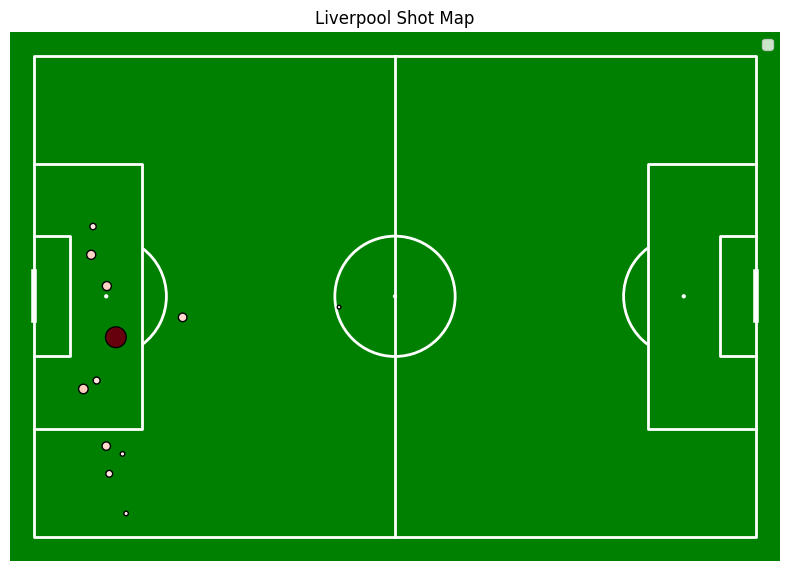

In [37]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    Liverpool["x"],
    Liverpool["y"],
    s=Liverpool["xg"]*600,
    c=Liverpool["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Liverpool Shot Map")
plt.legend()
plt.show()

In [38]:
import numpy as np

# Assuming goal is at x=120, y=40 (center of goal)
shots_df['distance'] = np.sqrt((120 - shots_df['x'])**2 + (40 - shots_df['y'])**2)

In [39]:
print(shots_df.columns)

Index(['player', 'team_home', 'shot_type', 'situation', 'body_part', 'x', 'y',
       'xg', 'minute', 'distance'],
      dtype='object')


In [40]:
import pandas as pd

# Aggregate per player
player_features = shots_df.groupby('player').agg({
    'x': 'mean',
    'y': 'mean',
    'xg': 'mean'
}).reset_index()

# Rename columns
player_features.columns = ['player','x','y','xg']

In [41]:
from sklearn.preprocessing import StandardScaler

features = ['x','y','xg']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(player_features[features])

In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
player_features['cluster'] = kmeans.fit_predict(X_scaled)

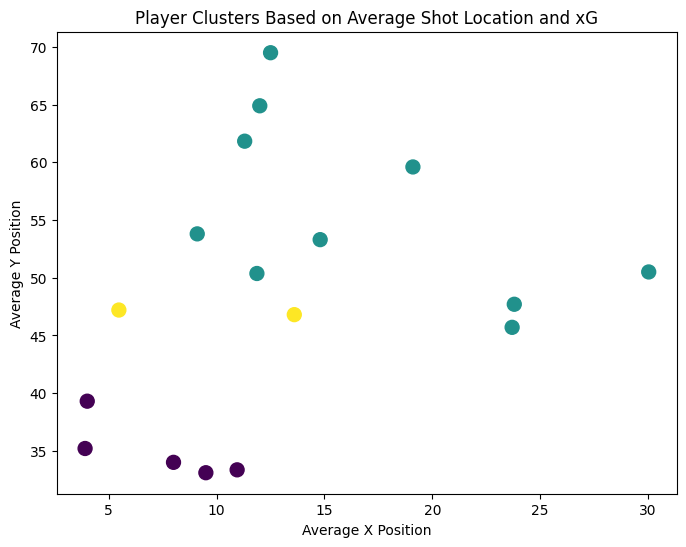

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(player_features['x'], player_features['y'],
            c=player_features['cluster'], cmap='viridis', s=100)
plt.xlabel('Average X Position')
plt.ylabel('Average Y Position')
plt.title('Player Clusters Based on Average Shot Location and xG')
plt.show()

In [44]:
player_features = shots_df.groupby('player', as_index=False).agg({
    'x': 'mean',
    'y': 'mean',
    'xg': 'mean',
    'distance': 'mean'
})

# Columns will be: player, x, y, xg, distance
print(player_features.head())

                player          x          y        xg    distance
0  Alexis Mac Allister  11.300000  61.833333  0.045747  111.365006
1           Cody Gakpo  10.950000  33.350000  0.052579  109.361118
2         Curtis Jones  12.000000  64.900000  0.061128  110.833253
3        Danny Welbeck   5.466667  47.200000  0.358076  114.771575
4          Diego Gómez  11.866667  50.366667  0.118191  110.139101


In [45]:
from sklearn.preprocessing import StandardScaler

features = ['x','y','xg','distance']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(player_features[features])

In [46]:
from sklearn.cluster import KMeans

# You can change n_clusters based on your data
kmeans = KMeans(n_clusters=3, random_state=42)
player_features['cluster'] = kmeans.fit_predict(X_scaled)

In [47]:
print(player_features[['player','x','y','xg','distance','cluster']])

                 player          x          y        xg    distance  cluster
0   Alexis Mac Allister  11.300000  61.833333  0.045747  111.365006        1
1            Cody Gakpo  10.950000  33.350000  0.052579  109.361118        0
2          Curtis Jones  12.000000  64.900000  0.061128  110.833253        1
3         Danny Welbeck   5.466667  47.200000  0.358076  114.771575        2
4           Diego Gómez  11.866667  50.366667  0.118191  110.139101        0
5    Dominik Szoboszlai  30.033333  50.500000  0.030891   91.066043        1
6       Federico Chiesa   9.500000  33.100000  0.071349  110.715220        0
7        Ferdi Kadıoğlu  23.700000  45.700000  0.021566   96.468544        1
8         Florian Wirtz  12.500000  69.500000  0.039403  111.474212        1
9      Jack Hinshelwood  23.800000  47.700000  0.043337   96.507668        1
10         James Milner  19.100000  59.600000  0.033505  102.811308        1
11   Jan Paul van Hecke   4.000000  39.300000  0.045229  116.002112        0

In [48]:
import pandas as pd

# Define 3 xG categories: low, medium, high
player_features['xG_cluster'] = pd.qcut(
    player_features['xg'],  # average xG per player
    q=3,                    # 3 quantiles
    labels=['low-quality shooters','moderate-quality shooters','top shooters']
)

# Show the result
print(player_features[['player','xg','xG_cluster']])

                 player        xg                 xG_cluster
0   Alexis Mac Allister  0.045747  moderate-quality shooters
1            Cody Gakpo  0.052579  moderate-quality shooters
2          Curtis Jones  0.061128  moderate-quality shooters
3         Danny Welbeck  0.358076               top shooters
4           Diego Gómez  0.118191               top shooters
5    Dominik Szoboszlai  0.030891       low-quality shooters
6       Federico Chiesa  0.071349  moderate-quality shooters
7        Ferdi Kadıoğlu  0.021566       low-quality shooters
8         Florian Wirtz  0.039403       low-quality shooters
9      Jack Hinshelwood  0.043337       low-quality shooters
10         James Milner  0.033505       low-quality shooters
11   Jan Paul van Hecke  0.045229       low-quality shooters
12         Kaoru Mitoma  0.098976               top shooters
13         Mats Wieffer  0.084748               top shooters
14         Miloš Kerkez  0.372082               top shooters
15       Yankuba Minteh 

In [49]:
# Map cluster names to colors
cluster_colors = {
    'low-quality shooters': 'red',
    'moderate-quality shooters': 'orange',
    'top shooters': 'green'
}

player_features['color'] = player_features['xG_cluster'].map(cluster_colors)

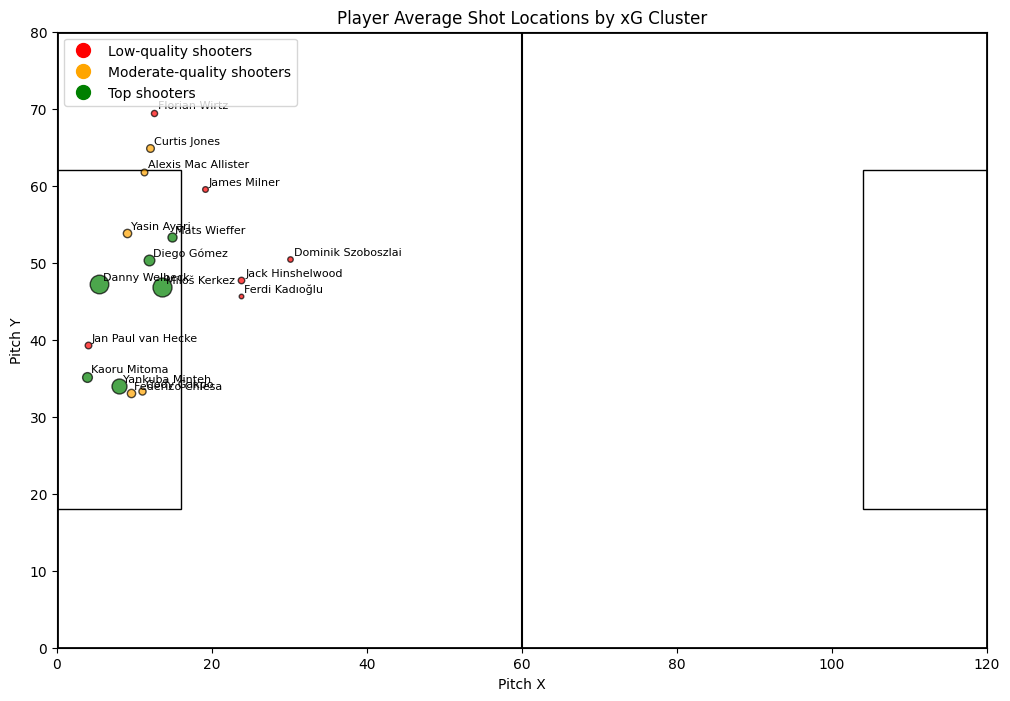

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure
fig, ax = plt.subplots(figsize=(12, 8))

# Draw pitch
pitch_length = 120
pitch_width = 80

# Outline
ax.add_patch(patches.Rectangle((0,0), pitch_length, pitch_width, edgecolor='black', fill=False, lw=2))

# Optional: penalty areas
ax.add_patch(patches.Rectangle((104, 18), 16, 44, edgecolor='black', fill=False, lw=1))
ax.add_patch(patches.Rectangle((0, 18), 16, 44, edgecolor='black', fill=False, lw=1))

# Center line
ax.plot([pitch_length/2, pitch_length/2], [0, pitch_width], color='black')

# Scatter players by avg shot location
for _, row in player_features.iterrows():
    ax.scatter(
        row['x'], row['y'],
        color=row['color'],
        s=row['xg']*500,   # size proportional to xG
        alpha=0.7,
        edgecolor='black'
    )
    # Optional: annotate player name
    ax.text(row['x']+0.5, row['y']+0.5, row['player'], fontsize=8)

# Labels
ax.set_xlim(0, pitch_length)
ax.set_ylim(0, pitch_width)
ax.set_xlabel('Pitch X')
ax.set_ylabel('Pitch Y')
ax.set_title('Player Average Shot Locations by xG Cluster')

# Legend
import matplotlib.lines as mlines
low = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Low-quality shooters')
moderate = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=10, label='Moderate-quality shooters')
top = mlines.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='Top shooters')
ax.legend(handles=[low, moderate, top], loc='upper left')

plt.show()

[]

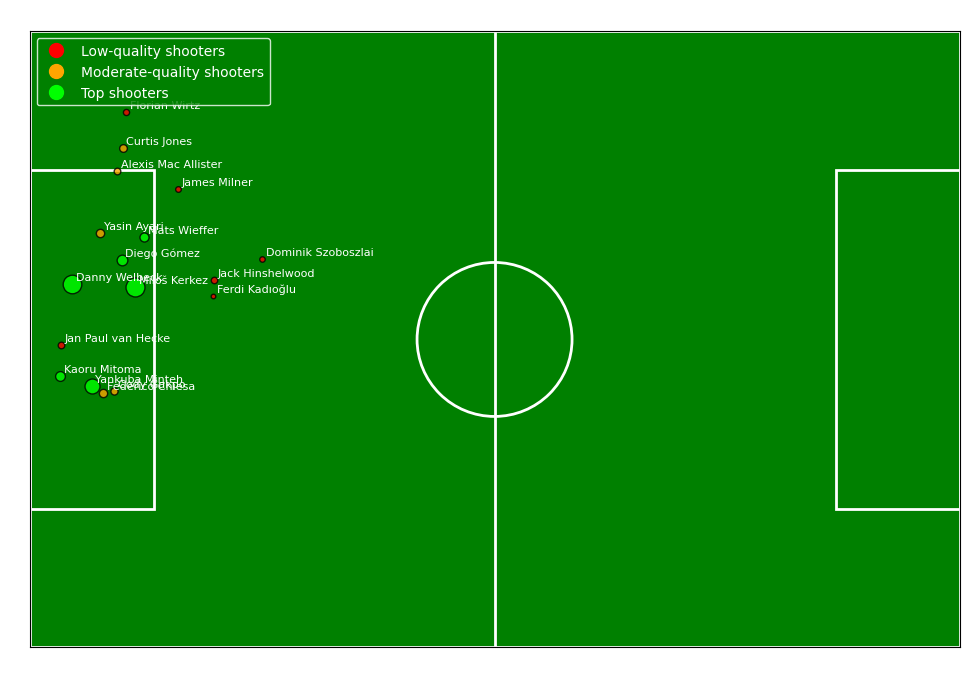

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

pitch_length = 120
pitch_width = 80

# Draw pitch background (green)
ax.add_patch(patches.Rectangle((0,0), pitch_length, pitch_width, edgecolor='white', facecolor='green', lw=2))

# Draw pitch markings in white
# Penalty areas
ax.add_patch(patches.Rectangle((104, 18), 16, 44, edgecolor='white', fill=False, lw=2))
ax.add_patch(patches.Rectangle((0, 18), 16, 44, edgecolor='white', fill=False, lw=2))
# Center line
ax.plot([pitch_length/2, pitch_length/2], [0, pitch_width], color='white', lw=2)
# Optional: center circle
center_circle = patches.Circle((pitch_length/2, pitch_width/2), 10, edgecolor='white', fill=False, lw=2)
ax.add_patch(center_circle)

# Scatter players by avg shot location
cluster_colors = {
    'low-quality shooters': 'red',
    'moderate-quality shooters': 'orange',
    'top shooters': 'lime'
}

player_features['color'] = player_features['xG_cluster'].map(cluster_colors)

for _, row in player_features.iterrows():
    ax.scatter(
        row['x'], row['y'],
        color=row['color'],
        s=row['xg']*500,   # size proportional to xG
        alpha=0.8,
        edgecolor='black'
    )
    ax.text(row['x']+0.5, row['y']+0.5, row['player'], fontsize=8, color='white')

# Labels
ax.set_xlim(0, pitch_length)
ax.set_ylim(0, pitch_width)
ax.set_xlabel('Pitch X', color='white')
ax.set_ylabel('Pitch Y', color='white')
ax.set_title('Player Average Shot Locations by xG Cluster', color='white')

# Legend
low = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Low-quality shooters')
moderate = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=10, label='Moderate-quality shooters')
top = mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=10, label='Top shooters')
ax.legend(handles=[low, moderate, top], loc='upper left', facecolor='green', edgecolor='white', labelcolor='white')

# Remove axis ticks for cleaner look
ax.set_xticks([])
ax.set_yticks([])


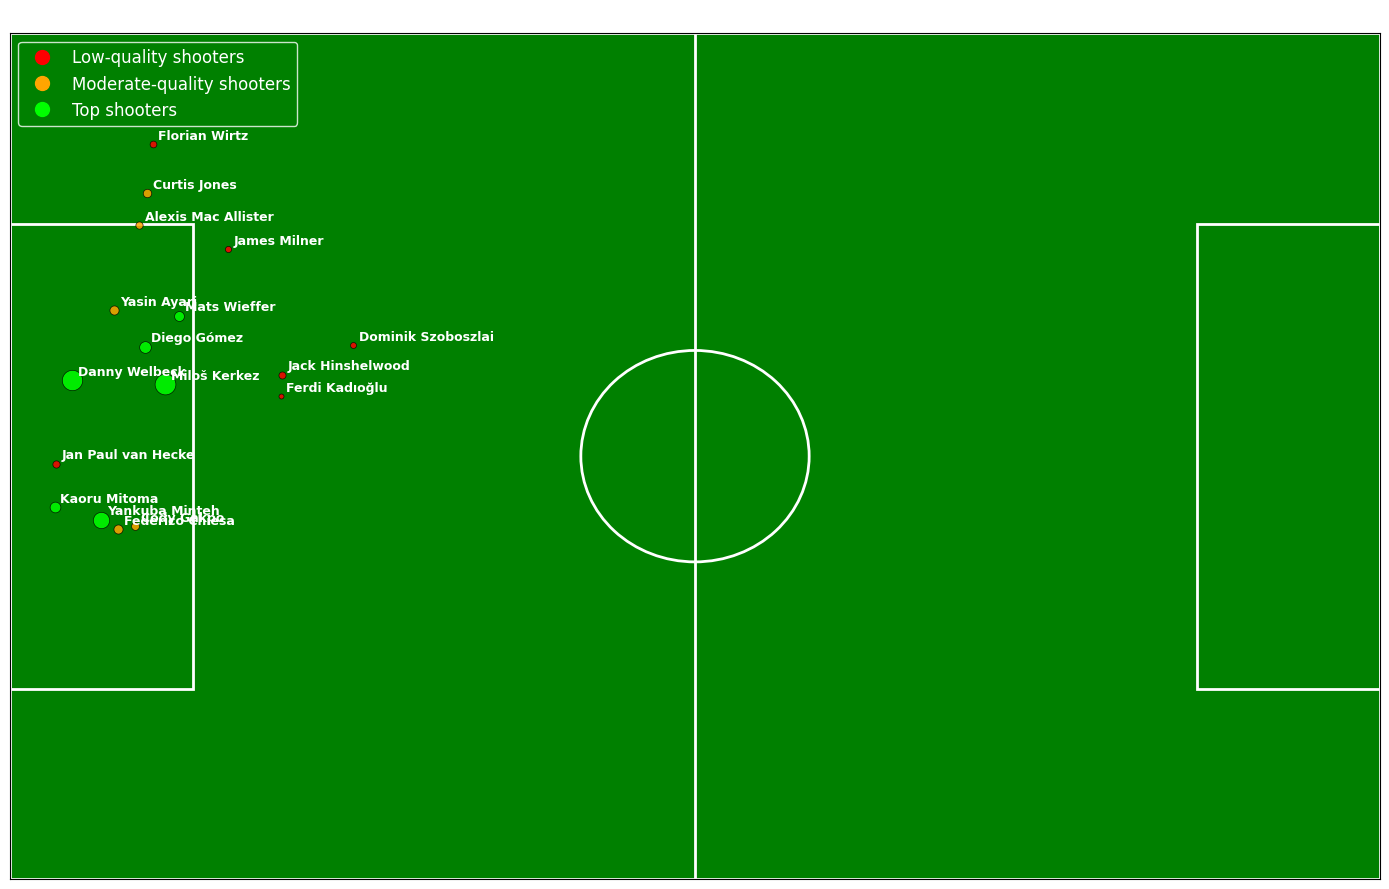

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines

# Figure setup
fig, ax = plt.subplots(figsize=(14, 9))
pitch_length = 120
pitch_width = 80

# Draw pitch background
ax.add_patch(patches.Rectangle((0,0), pitch_length, pitch_width, edgecolor='white', facecolor='green', lw=2))

# Pitch markings in white
# Penalty areas
ax.add_patch(patches.Rectangle((104, 18), 16, 44, edgecolor='white', fill=False, lw=2))
ax.add_patch(patches.Rectangle((0, 18), 16, 44, edgecolor='white', fill=False, lw=2))
# Center line
ax.plot([pitch_length/2, pitch_length/2], [0, pitch_width], color='white', lw=2)
# Center circle
center_circle = patches.Circle((pitch_length/2, pitch_width/2), 10, edgecolor='white', fill=False, lw=2)
ax.add_patch(center_circle)

# Colors for clusters
cluster_colors = {
    'low-quality shooters': 'red',
    'moderate-quality shooters': 'orange',
    'top shooters': 'lime'
}
player_features['color'] = player_features['xG_cluster'].map(cluster_colors)

# Scatter players
for _, row in player_features.iterrows():
    ax.scatter(
        row['x'], row['y'],
        color=row['color'],
        s=row['xg']*600,   # scale marker by xG
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )
    # Annotate player names
    ax.text(row['x']+0.5, row['y']+0.5, row['player'], fontsize=9, color='white', weight='bold')

# Labels and title
ax.set_xlim(0, pitch_length)
ax.set_ylim(0, pitch_width)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Player Average Shot Locations by xG Cluster', fontsize=16, color='white', weight='bold')

# Legend
low = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Low-quality shooters')
moderate = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=10, label='Moderate-quality shooters')
top = mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=10, label='Top shooters')
ax.legend(handles=[low, moderate, top], loc='upper left', facecolor='green', edgecolor='white', labelcolor='white', fontsize=12)

# Clean layout
ax.set_facecolor('green')
plt.tight_layout()
plt.show()